# 05 - Reference Checks

- This notebook rebuilds the reference check plots for the cleaned Step 2 data.
- PLDI is included as a conference in the cleaned data.

## 1. Setup

In [1]:
import sys
from pathlib import Path

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "project_setup.py").exists() and (candidate / "config" / "project_config.yaml").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise RuntimeError(
        "Could not find the repository root. Launch Jupyter from the repo root "
        "or set PYTHONPATH to the folder containing project_setup.py."
    )

import sys
import json
import re
import unicodedata
from pathlib import Path

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "config" / "project_config.yaml").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from project_setup import setup_project

setup = setup_project()
PROJECT = setup.project_folder
project_folder = setup.project_folder

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
from tqdm import tqdm

from plot import set_size

# Paper-ready style used across the report figures.
fontpath = PROJECT / "fonts" / "LinLibertine_R.ttf"
prop = font_manager.FontProperties(fname=fontpath)
mpl.rcParams.update({
    "axes.titlesize" : 14,
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "font.family": prop.get_name(),
    "text.usetex": True,
})

DATA = PROJECT / "step_2_data"
ARTIFACTS = PROJECT / "step_2_artifacts"
IMAGES = ARTIFACTS / "figures"
TABLES = ARTIFACTS / "summary_tables"
IMAGES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

ISSUE_ORDER = ["ICFP", "POPL", "OOPSLA", "OOPSLA1", "OOPSLA2", "PLDI"]
COLORS = {
    "ICFP": "#f4b8e4",
    "POPL": "#81c8be",
    "OOPSLA": "#7287fd",
    "OOPSLA1": "#9aa6f7",
    "OOPSLA2": "#5a72e0",
    "PLDI": "#e5c890",
}

print(PROJECT)


/Users/endersari/2026-02-citations-vs-pc-memberships


## 2. Load inputs and build plotting frames


In [2]:
# Clean Step 2 inputs
# `df_filtered` and `ref_result` are used by the plotting code below.
df_filtered = pd.read_parquet(DATA / "prepared" / "all_papers" / "all_papers_filtered.parquet")
ref_result = pd.read_parquet(DATA / "prepared" / "all_papers" / "all_ref_authors_exploded.parquet")

print(f"df_filtered: {df_filtered.shape}")
print(f"ref_result:  {ref_result.shape}")
print(df_filtered.groupby(["issue", "conference_year"]).size().head())


df_filtered: (2528, 13)
ref_result:  (355366, 12)
issue  conference_year
ICFP   2017               44
       2018               40
       2019               39
       2020               36
       2021               35
dtype: int64


## 3. Build `m` (citation_count + ref_authorships_count per cited work)

This cell builds the plotting tables used by the checks below.
The conference level table keeps one row per `(issue, referenced_work_id)` so
the PLDI panels represent PLDI cited works directly.


In [3]:
def short_id(value):
    if value is None or pd.isna(value):
        return None
    return str(value).rstrip("/").rsplit("/", 1)[-1]

# referenced_authorships count: distinct OpenAlex author IDs and author names per cited work.
ref_count = (
    ref_result.groupby("referenced_work_id")
    .agg(
        ref_authorships_count=("ref_author_id", "nunique"),
        ref_author_name_count=("ref_author_name", "nunique"),
    )
    .reset_index()
)

# citation_count input: one citing-paper edge per reference.
citing_edges = (
    df_filtered[["work_id", "issue", "conference_year", "referenced_works"]]
    .explode("referenced_works")
    .rename(columns={"referenced_works": "referenced_work_id",
                     "conference_year": "year"})
)
citing_edges["referenced_work_id"] = citing_edges["referenced_work_id"].apply(short_id)
citing_edges = citing_edges.dropna(subset=["referenced_work_id"]).reset_index(drop=True)

# Overall frame: one row per cited work across the full selected corpus.
# This is the frame used by citation_distribution_referenced_papers.pdf.
global_t_vc = (
    citing_edges["referenced_work_id"]
    .value_counts()
    .rename("citation_count")
    .reset_index()
)
global_t_vc.columns = ["referenced_work_id", "citation_count"]

m_overall = (
    citing_edges
    .drop_duplicates(subset="referenced_work_id")
    .merge(ref_count, on="referenced_work_id", how="left")
    .merge(global_t_vc, on="referenced_work_id", how="left")
)
m_overall["ref_authorships_count"] = m_overall["ref_authorships_count"].fillna(0).astype(int)
m_overall["ref_author_name_count"] = m_overall["ref_author_name_count"].fillna(0).astype(int)
m_overall["citation_count"] = m_overall["citation_count"].fillna(0).astype(int)

# Conference-level frame: one row per issue-cited-work pair.
# This is used by the per-conference check panels, including PLDI.
issue_t_vc = (
    citing_edges.groupby(["issue", "referenced_work_id"])
    .size()
    .rename("citation_count")
    .reset_index()
)

m_by_issue = (
    citing_edges
    .drop_duplicates(subset=["issue", "referenced_work_id"])
    .merge(ref_count, on="referenced_work_id", how="left")
    .merge(issue_t_vc, on=["issue", "referenced_work_id"], how="left")
)
m_by_issue["ref_authorships_count"] = m_by_issue["ref_authorships_count"].fillna(0).astype(int)
m_by_issue["ref_author_name_count"] = m_by_issue["ref_author_name_count"].fillna(0).astype(int)
m_by_issue["citation_count"] = m_by_issue["citation_count"].fillna(0).astype(int)

# Yearly conference-level frame: one row per issue-year-cited-work pair.
# This is used only for missing-metadata trends over conference years.
issue_year_t_vc = (
    citing_edges.groupby(["issue", "year", "referenced_work_id"])
    .size()
    .rename("citation_count")
    .reset_index()
)

m_by_issue_year = (
    citing_edges
    .drop_duplicates(subset=["issue", "year", "referenced_work_id"])
    .merge(ref_count, on="referenced_work_id", how="left")
    .merge(issue_year_t_vc, on=["issue", "year", "referenced_work_id"], how="left")
)
m_by_issue_year["ref_authorships_count"] = m_by_issue_year["ref_authorships_count"].fillna(0).astype(int)
m_by_issue_year["ref_author_name_count"] = m_by_issue_year["ref_author_name_count"].fillna(0).astype(int)
m_by_issue_year["citation_count"] = m_by_issue_year["citation_count"].fillna(0).astype(int)

# Keep this variable name for compatibility with the plotting code below.
m = m_overall

m_counts = (
    m_by_issue.assign(author_info_available=m_by_issue["ref_authorships_count"] > 0)
    .groupby(["issue", "author_info_available"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={False: "author_info_missing", True: "author_info_available"})
    .reset_index()
)
m_counts["issue"] = pd.Categorical(m_counts["issue"], categories=ISSUE_ORDER, ordered=True)
m_counts = m_counts.sort_values("issue")
m_counts.to_csv(TABLES / "reference_check_plot_counts.csv", index=False)

overall_plot_counts = pd.DataFrame([
    {"scope": "global", "author_info_type": "author_id", "author_info": "available", "n": int((m_overall["ref_authorships_count"] > 0).sum())},
    {"scope": "global", "author_info_type": "author_id", "author_info": "missing", "n": int((m_overall["ref_authorships_count"] == 0).sum())},
    {"scope": "global", "author_info_type": "author_name", "author_info": "available", "n": int((m_overall["ref_author_name_count"] > 0).sum())},
    {"scope": "global", "author_info_type": "author_name", "author_info": "missing", "n": int((m_overall["ref_author_name_count"] == 0).sum())},
    {"scope": "conference", "author_info_type": "author_id", "author_info": "available", "n": int((m_by_issue["ref_authorships_count"] > 0).sum())},
    {"scope": "conference", "author_info_type": "author_id", "author_info": "missing", "n": int((m_by_issue["ref_authorships_count"] == 0).sum())},
    {"scope": "conference", "author_info_type": "author_name", "author_info": "available", "n": int((m_by_issue["ref_author_name_count"] > 0).sum())},
    {"scope": "conference", "author_info_type": "author_name", "author_info": "missing", "n": int((m_by_issue["ref_author_name_count"] == 0).sum())},
])
overall_plot_counts.to_csv(TABLES / "reference_check_overall_plot_counts.csv", index=False)

reference_check_summary = pd.DataFrame([
    {"metric": "accepted_papers", "value": int(df_filtered["work_id"].nunique())},
    {"metric": "reference_edges", "value": int(len(citing_edges))},
    {"metric": "unique_referenced_works_in_edges", "value": int(citing_edges["referenced_work_id"].nunique())},
    {"metric": "unique_referenced_works_with_authors", "value": int(ref_result["referenced_work_id"].nunique())},
    {"metric": "unique_cited_authors", "value": int(ref_result["ref_author_id"].nunique())},
    {"metric": "share_unique_cited_works_missing_author_ids", "value": float((m_overall["ref_authorships_count"] == 0).mean())},
    {"metric": "share_issue_cited_works_missing_author_ids", "value": float((m_by_issue["ref_authorships_count"] == 0).mean())},
    {"metric": "share_issue_cited_works_missing_author_names", "value": float((m_by_issue["ref_author_name_count"] == 0).mean())},
    {"metric": "median_reference_count_per_paper", "value": float(df_filtered["number_of_references"].median())},
    {"metric": "mean_reference_count_per_paper", "value": float(df_filtered["number_of_references"].mean())},
])

reference_check_by_issue = (
    m_by_issue.assign(missing_authors=m_by_issue["ref_authorships_count"] == 0)
    .groupby("issue")
    .agg(
        unique_cited_works=("referenced_work_id", "nunique"),
        total_issue_citation_links=("citation_count", "sum"),
        missing_author_share=("missing_authors", "mean"),
        median_citations_per_cited_work=("citation_count", "median"),
        mean_citations_per_cited_work=("citation_count", "mean"),
    )
    .reset_index()
)
reference_check_by_issue["issue"] = pd.Categorical(
    reference_check_by_issue["issue"], categories=ISSUE_ORDER, ordered=True
)
reference_check_by_issue = reference_check_by_issue.sort_values("issue")

reference_author_missing_by_conference_year = (
    m_by_issue_year.assign(missing_authors=m_by_issue_year["ref_authorships_count"] == 0)
    .groupby(["issue", "year"])
    .agg(
        unique_cited_works=("referenced_work_id", "nunique"),
        missing_author_works=("missing_authors", "sum"),
        missing_author_share=("missing_authors", "mean"),
    )
    .reset_index()
    .rename(columns={"year": "conference_year"})
)

reference_check_summary.to_csv(TABLES / "reference_check_summary.csv", index=False)
reference_check_by_issue.to_csv(TABLES / "reference_check_by_issue.csv", index=False)
reference_author_missing_by_conference_year.to_csv(
    TABLES / "missing_authors_by_year.csv", index=False
)

print(f"m_overall: {m_overall.shape}")
print(f"m_by_issue: {m_by_issue.shape}")
print(f"m_by_issue_year: {m_by_issue_year.shape}")
print(overall_plot_counts)
print(m_counts)


m_overall: (44334, 7)
m_by_issue: (69628, 7)
m_by_issue_year: (96383, 7)
        scope author_info_type author_info      n
0      global        author_id   available  38660
1      global        author_id     missing   5674
2      global      author_name   available  40774
3      global      author_name     missing   3560
4  conference        author_id   available  61530
5  conference        author_id     missing   8098
6  conference      author_name   available  64415
7  conference      author_name     missing   5213
author_info_available    issue  author_info_missing  author_info_available
0                         ICFP                  845                   7028
5                         POPL                 1672                  13002
1                       OOPSLA                 1010                  10279
2                      OOPSLA1                  918                   5350
3                      OOPSLA2                 1465                  10010
4                         P

## 4. Duplicate OpenAlex work IDs for the same cited title

I also check whether the same cited paper title appears under more than one OpenAlex work ID. This is not a perfect duplicate detector, but it is a useful check because the panel counts references to OpenAlex work IDs.

In [4]:
OPENALEX_WORK_CACHE = DATA / "raw" / "openalex_cache" / "2026-06-11" / "works"
DUPLICATE_TITLE_SUMMARY = TABLES / "openalex_duplicate_cited_title_summary.csv"
DUPLICATE_TITLE_EXPLODED = TABLES / "duplicate_titles_exploded.csv"
DUPLICATE_TITLE_RAW_EDGES = TABLES / "duplicate_titles_ref_edges.csv"


def normalize_title_for_duplicate_check(title):
    if title is None or pd.isna(title):
        return None
    title = unicodedata.normalize("NFKC", str(title)).casefold()
    title = title.replace("&", " and ")
    title = re.sub(r"[^\w\s]+", " ", title)
    title = re.sub(r"\s+", " ", title).strip()
    return title or None


def load_cached_work_metadata(work_ids):
    rows = []
    missing = {"missing_json": 0, "null_json": 0, "missing_title": 0}

    for work_id in sorted(set(pd.Series(work_ids).dropna().astype(str))):
        path = OPENALEX_WORK_CACHE / f"{work_id}.json"
        if not path.exists():
            missing["missing_json"] += 1
            continue

        data = json.loads(path.read_text())
        if not isinstance(data, dict):
            missing["null_json"] += 1
            continue

        title = data.get("title") or data.get("display_name")
        title_key = normalize_title_for_duplicate_check(title)
        if not title_key:
            missing["missing_title"] += 1
            continue

        rows.append({
            "referenced_work_id": work_id,
            "title": title,
            "title_key": title_key,
            "doi": data.get("doi"),
            "publication_year": data.get("publication_year"),
            "type": data.get("type"),
            "cited_by_count": data.get("cited_by_count"),
        })

    return pd.DataFrame(rows), missing


def build_duplicate_title_tables_from_cache():
    exploded_work_ids = ref_result["referenced_work_id"].dropna().astype(str).unique()
    work_meta, missing_duplicate_title_metadata = load_cached_work_metadata(exploded_work_ids)
    if work_meta.empty or "title_key" not in work_meta.columns:
        raise FileNotFoundError("No cached OpenAlex work-title metadata available.")

    duplicate_title_groups = (
        work_meta
        .groupby("title_key")
        .agg(
            n_openalex_work_ids=("referenced_work_id", "nunique"),
            representative_title=("title", "first"),
            work_ids=("referenced_work_id", lambda values: "; ".join(sorted(set(values)))),
            years=("publication_year", lambda values: ", ".join(
                str(int(value)) for value in sorted(set(values.dropna())) if pd.notna(value)
            )),
        )
        .reset_index()
    )
    duplicate_title_groups = duplicate_title_groups[duplicate_title_groups["n_openalex_work_ids"] > 1].copy()

    n_titled_work_ids = work_meta["referenced_work_id"].nunique()
    n_title_groups = work_meta["title_key"].nunique()
    n_duplicate_title_groups = duplicate_title_groups.shape[0]
    exploded_title_keys = ref_result[["referenced_work_id"]].merge(
        work_meta[["referenced_work_id", "title_key"]],
        on="referenced_work_id",
        how="left",
    )

    # Reference-edge version: useful for understanding the raw citation graph before author expansion.
    raw_reference_work_ids = citing_edges["referenced_work_id"].dropna().astype(str).unique()
    raw_work_meta, raw_missing_duplicate_title_metadata = load_cached_work_metadata(raw_reference_work_ids)
    if raw_work_meta.empty or "title_key" not in raw_work_meta.columns:
        raise FileNotFoundError("No cached OpenAlex work-title metadata available for raw reference edges.")

    raw_title_groups = (
        raw_work_meta
        .groupby("title_key")
        .agg(
            n_openalex_work_ids=("referenced_work_id", "nunique"),
            representative_title=("title", "first"),
            work_ids=("referenced_work_id", lambda values: "; ".join(sorted(set(values)))),
            years=("publication_year", lambda values: ", ".join(
                str(int(value)) for value in sorted(set(values.dropna())) if pd.notna(value)
            )),
        )
        .reset_index()
    )
    raw_duplicate_title_groups = raw_title_groups[raw_title_groups["n_openalex_work_ids"] > 1].copy()

    raw_edges_with_titles = citing_edges[["referenced_work_id"]].merge(
        raw_work_meta[["referenced_work_id", "title_key"]],
        on="referenced_work_id",
        how="left",
    )

    openalex_duplicate_title_summary = pd.DataFrame([
        {
            "scope": "exploded_author_set",
            "unique_referenced_work_ids": int(ref_result["referenced_work_id"].nunique()),
            "unique_work_ids_with_title": int(n_titled_work_ids),
            "unique_title_groups": int(n_title_groups),
            "title_groups_with_multiple_work_ids": int(n_duplicate_title_groups),
            "pct_title_groups_with_multiple_work_ids": 100 * n_duplicate_title_groups / n_title_groups,
        },
        {
            "scope": "raw_reference_edges",
            "unique_referenced_work_ids": int(citing_edges["referenced_work_id"].nunique()),
            "unique_work_ids_with_title": int(raw_work_meta["referenced_work_id"].nunique()),
            "unique_title_groups": int(raw_work_meta["title_key"].nunique()),
            "title_groups_with_multiple_work_ids": int(raw_duplicate_title_groups.shape[0]),
            "pct_title_groups_with_multiple_work_ids": 100 * raw_duplicate_title_groups.shape[0] / raw_work_meta["title_key"].nunique(),
        },
    ])

    # Add a row-count column to the detail tables so common examples are easy to inspect.
    exploded_title_row_counts = (
        exploded_title_keys
        .groupby("title_key")
        .size()
        .rename("exploded_author_rows")
        .reset_index()
    )
    duplicate_title_groups = duplicate_title_groups.merge(exploded_title_row_counts, on="title_key", how="left")
    duplicate_title_groups = duplicate_title_groups.sort_values(
        ["n_openalex_work_ids", "exploded_author_rows"],
        ascending=False,
    )

    raw_edge_counts = (
        raw_edges_with_titles
        .groupby("title_key")
        .size()
        .rename("raw_reference_edges")
        .reset_index()
    )
    raw_duplicate_title_groups = raw_duplicate_title_groups.merge(raw_edge_counts, on="title_key", how="left")
    raw_duplicate_title_groups = raw_duplicate_title_groups.sort_values(
        ["n_openalex_work_ids", "raw_reference_edges"],
        ascending=False,
    )

    openalex_duplicate_title_summary.to_csv(DUPLICATE_TITLE_SUMMARY, index=False)
    duplicate_title_groups.to_csv(DUPLICATE_TITLE_EXPLODED, index=False)
    raw_duplicate_title_groups.to_csv(DUPLICATE_TITLE_RAW_EDGES, index=False)

    return (
        openalex_duplicate_title_summary,
        duplicate_title_groups,
        raw_duplicate_title_groups,
        {"exploded": missing_duplicate_title_metadata, "raw_reference_edges": raw_missing_duplicate_title_metadata},
        "raw OpenAlex work cache",
    )


def load_duplicate_title_tables_from_artifacts():
    required = [DUPLICATE_TITLE_SUMMARY, DUPLICATE_TITLE_EXPLODED, DUPLICATE_TITLE_RAW_EDGES]
    missing = [str(path) for path in required if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "Duplicate-title summary tables are missing and the raw OpenAlex work cache is not available: "
            + ", ".join(missing)
        )

    return (
        pd.read_csv(DUPLICATE_TITLE_SUMMARY),
        pd.read_csv(DUPLICATE_TITLE_EXPLODED),
        pd.read_csv(DUPLICATE_TITLE_RAW_EDGES),
        {"loaded_from_summary_tables": True},
        "cached summary tables",
    )


try:
    (
        openalex_duplicate_title_summary,
        duplicate_title_groups,
        raw_duplicate_title_groups,
        duplicate_title_metadata_status,
        duplicate_title_source,
    ) = build_duplicate_title_tables_from_cache()
except FileNotFoundError:
    (
        openalex_duplicate_title_summary,
        duplicate_title_groups,
        raw_duplicate_title_groups,
        duplicate_title_metadata_status,
        duplicate_title_source,
    ) = load_duplicate_title_tables_from_artifacts()

print(f"Duplicate-title check source: {duplicate_title_source}")
print("Exploded author set")
print(openalex_duplicate_title_summary.iloc[[0]].to_string(index=False))
print("\nRaw reference-edge set")
print(openalex_duplicate_title_summary.iloc[[1]].to_string(index=False))
print("\nMetadata status during duplicate-title check")
print(duplicate_title_metadata_status)
print("\nTop duplicate-title examples in the exploded author set")
display(duplicate_title_groups[[
    "representative_title",
    "n_openalex_work_ids",
    "exploded_author_rows",
    "years",
    "work_ids",
]].head(15))


Duplicate-title check source: cached summary tables
Exploded author set
              scope  unique_referenced_work_ids  unique_work_ids_with_title  unique_title_groups  title_groups_with_multiple_work_ids  pct_title_groups_with_multiple_work_ids
exploded_author_set                       40774                       40712                37283                                 3111                                 8.344286

Raw reference-edge set
              scope  unique_referenced_work_ids  unique_work_ids_with_title  unique_title_groups  title_groups_with_multiple_work_ids  pct_title_groups_with_multiple_work_ids
raw_reference_edges                       44334                       41506                37987                                 3165                                 8.331798

Metadata status during duplicate-title check
{'loaded_from_summary_tables': True}

Top duplicate-title examples in the exploded author set


,representative_title,n_openalex_work_ids,exploded_author_rows,years,work_ids
0,Tools and Algorithms for the Construction and ...,15,114,"1998, 2001, 2009, 2010, 2011, 2012, 2015, 2016...",W1639713563; W1662203549; W2487425287; W249081...
1,Introduction to Algorithms,12,97,"1990, 1991, 1996, 2005, 2008, 2009, 2018, 2020...",W2752573522; W2752885492; W2946046356; W301936...
2,Computer Aided Verification,12,30,"1993, 1999, 2006, 2010, 2014, 2015, 2016, 2017...",W2238621239; W2496887306; W2498950568; W249972...
3,Programming Languages and Systems,11,68,"2006, 2009, 2010, 2012, 2014, 2016, 2022, 2023...",W1587388778; W1611801415; W2490124688; W249191...
4,The Coq Proof Assistant,11,32,"2018, 2019, 2020, 2021, 2022, 2023, 2024",W4205631450; W6893240590; W6893793464; W689395...
5,Foundations of Software Science and Computatio...,8,37,"1999, 2002, 2006, 2013, 2018, 2019, 2023, 2025",W2136038607; W2476467509; W2487685844; W248934...
6,Experience report,7,32,"2009, 2010, 2012, 2013, 2014, 2018",W2044948261; W2076015358; W2076668269; W210464...
7,Brief announcement,6,85,"2012, 2014, 2016, 2017, 2018",W2009454615; W2098297530; W2470481370; W273854...
8,Probability and Measure.,6,24,"1983, 1987, 1996, 2009, 2010",W2056099894; W2188564768; W4298443330; W430057...
9,Dynamo,5,171,"2000, 2007, 2011",W2072737419; W2153704625; W4231002400; W423257...


## 5. Plot — Author count per cited paper


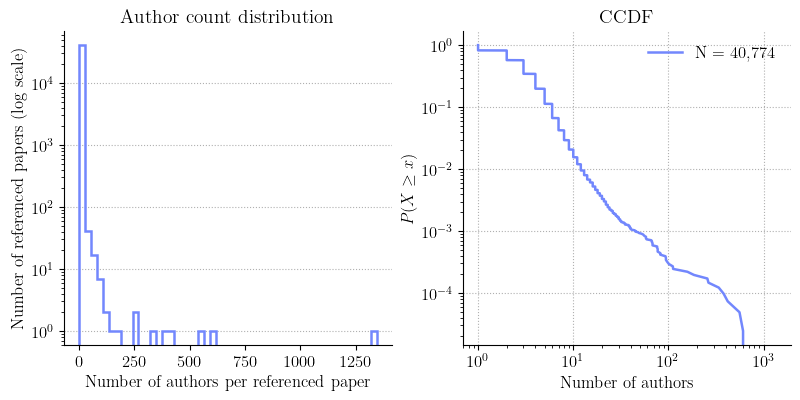

In [5]:
import numpy as np
import matplotlib.pyplot as plt
vals = ref_result.groupby('referenced_work_id')['ref_author_name'].nunique()

# data
x = vals.dropna().values
N = len(x)

x_sorted = np.sort(x)
ccdf = 1 - np.arange(1, len(x_sorted)+1) / len(x_sorted)

fig, axs = plt.subplots(1, 2, figsize=(7,3), constrained_layout=True)

# --- histogram ---
ax = axs[0]
ax.hist(
    x,
    bins=50,
    log=True,
    histtype="step",
    linewidth=1.8,
    color="#7287fd"
)

ax.set_xlabel("Number of authors per referenced paper")
ax.set_ylabel("Number of referenced papers (log scale)")
ax.set_title("Author count distribution")

ax.grid(axis="y", ls=":", linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --- CCDF ---
ax = axs[1]
line, = ax.plot(
    x_sorted,
    ccdf,
    color="#7287fd",
    linewidth=1.8
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Number of authors")
ax.set_ylabel(r"$P(X \geq x)$")
ax.set_title("CCDF")

ax.legend([line], [f"N = {N:,}"], loc="upper right", frameon=False)

ax.grid(axis="both", ls=":", linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
set_size(fig, size=(8,4))
fig.savefig(IMAGES / "number_of_authors_for_referenced_work.pdf", bbox_inches="tight")
plt.show()


## 6. Plot — Author count per cited paper, per issue

OOPSLA1 / OOPSLA2 are shown alongside OOPSLA so the rolling OOPSLA structure remains visible.


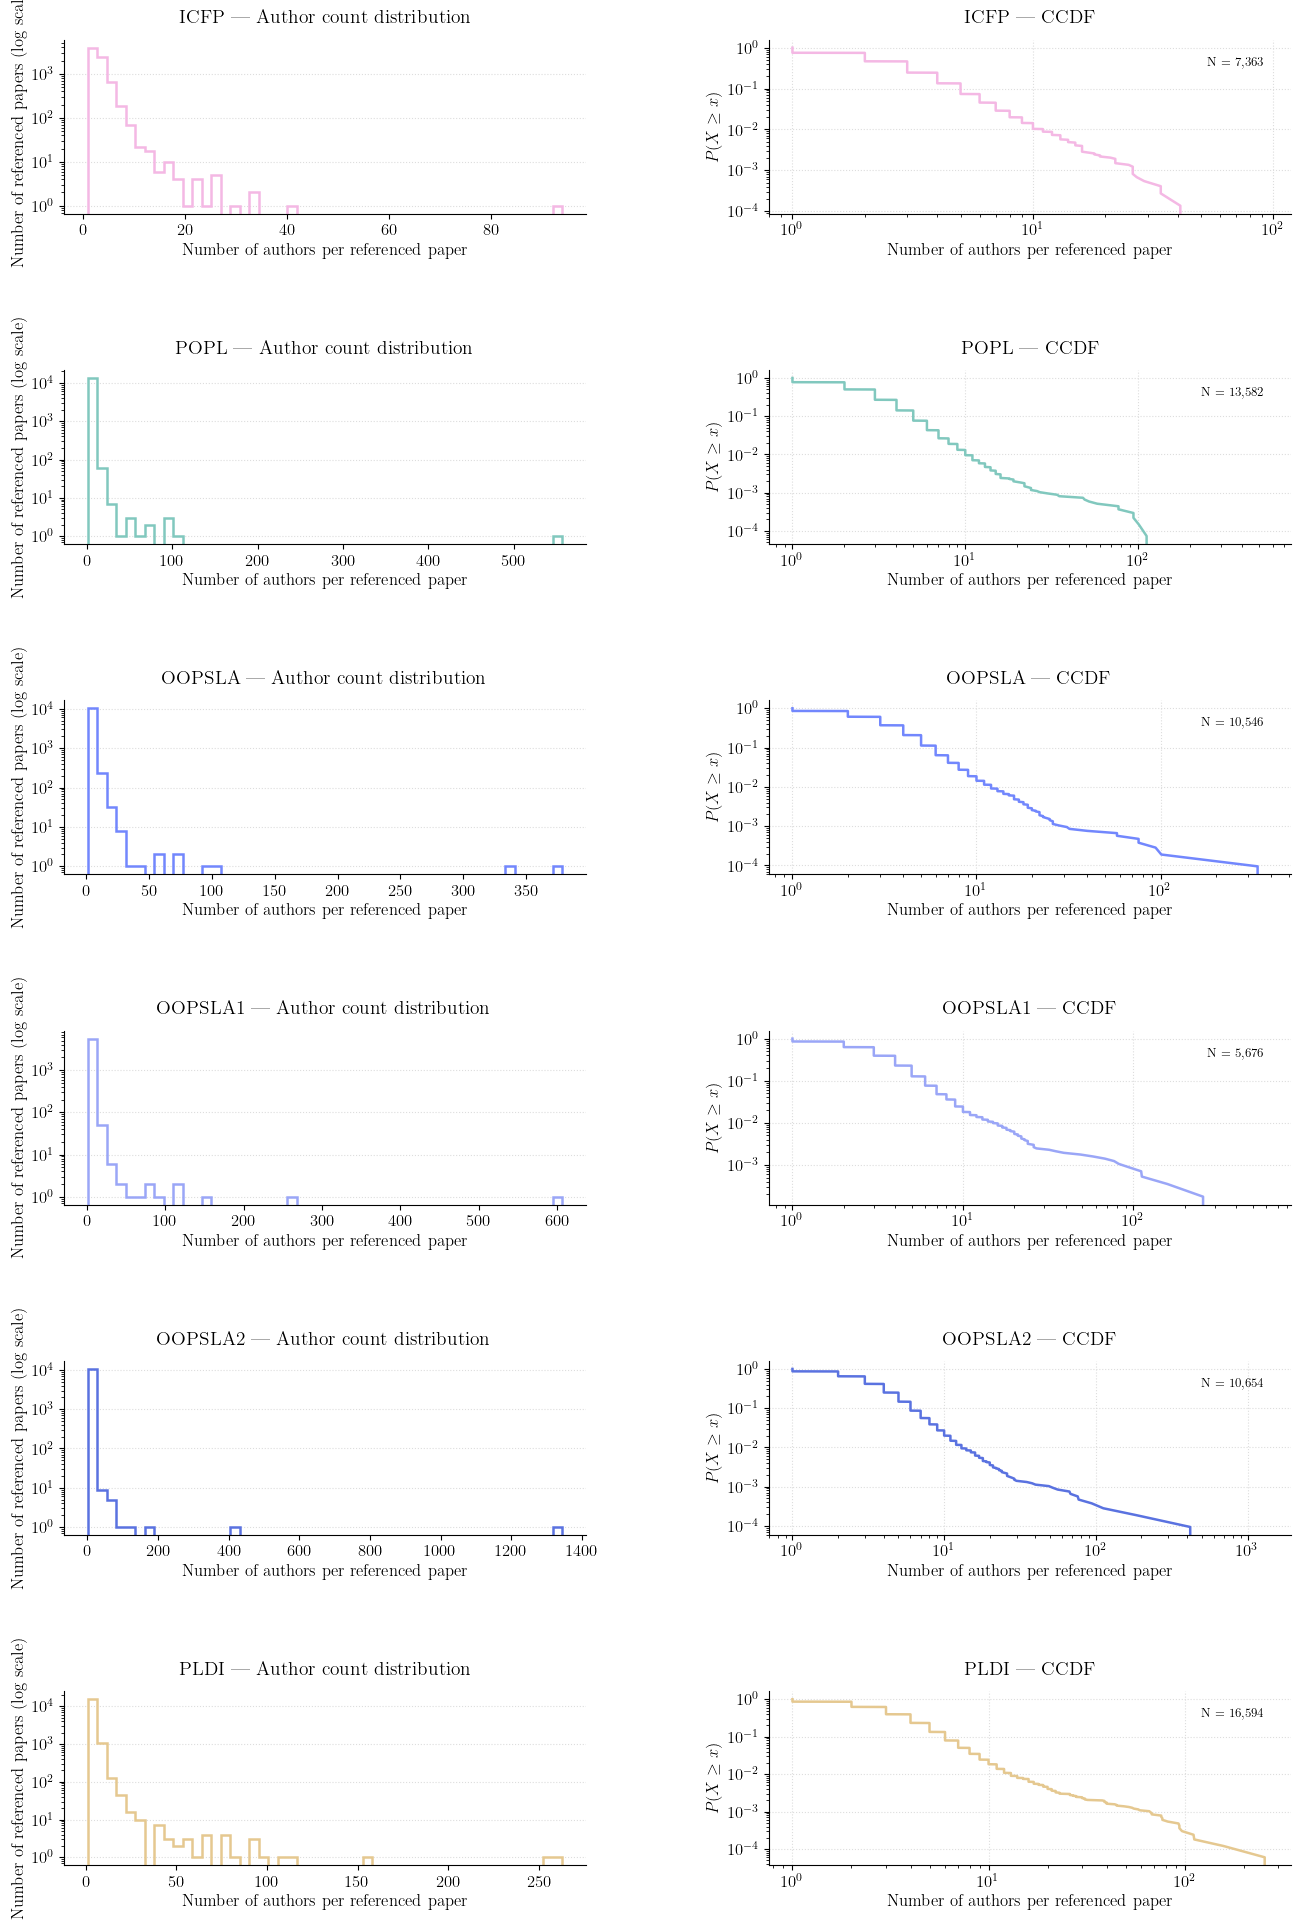

In [6]:
import numpy as np
import matplotlib.pyplot as plt

colors = {
    "ICFP": "#f4b8e4",
    "POPL": "#81c8be",
    "OOPSLA": "#7287fd",
    "OOPSLA1": "#9aa6f7",
    "OOPSLA2": "#5a72e0",
    "PLDI": "#e5c890",
}

issue_order = [i for i in ISSUE_ORDER
               if (ref_result["issue"] == i).any()]

fig, axs = plt.subplots(
    len(issue_order), 2,
    figsize=(8, 4*len(issue_order))
)

# Increase spacing so per-row titles do not collide with x-axis labels above.
fig.subplots_adjust(hspace=0.9, wspace=0.35)

for i, issue in enumerate(issue_order):

    # --- compute vals ---
    vals = ref_result[ref_result["issue"] == issue] \
        .groupby("referenced_work_id")["ref_author_name"].nunique()

    x = vals.dropna().values
    N = len(x)

    x_sorted = np.sort(x)
    ccdf = 1 - np.arange(1, len(x_sorted)+1) / len(x_sorted)

    color = colors[issue]

    # -------------------
    # Histogram
    # -------------------
    ax = axs[i, 0]

    ax.hist(
        x,
        bins=50,
        log=True,
        histtype="step",
        linewidth=1.8,
        color=color
    )

    ax.set_title(f"{issue} — Author count distribution", pad=12)
    ax.set_xlabel("Number of authors per referenced paper")
    ax.set_ylabel("Number of referenced papers (log scale)")

    ax.grid(axis="y", color="#DDDDDD", ls=":", linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # -------------------
    # CCDF
    # -------------------
    ax = axs[i, 1]

    ax.plot(
        x_sorted,
        ccdf,
        color=color,
        linewidth=1.8
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_title(f"{issue} — CCDF", pad=12)
    ax.set_xlabel("Number of authors per referenced paper")
    ax.set_ylabel(r"$P(X \geq x)$")

    # N label (upper right)
    ax.text(
        0.95, 0.90,
        f"N = {N:,}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9
    )

    ax.grid(axis="both", color="#DDDDDD", ls=":", linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
# Scale final size with the number of conference panels.
set_size(fig, size=(13, 3.2 * len(issue_order)))
fig.savefig(IMAGES / "number_of_authors_for_referenced_work_conferences.pdf",bbox_inches="tight")
plt.show()


## 7. Plot — Citation distribution of cited papers


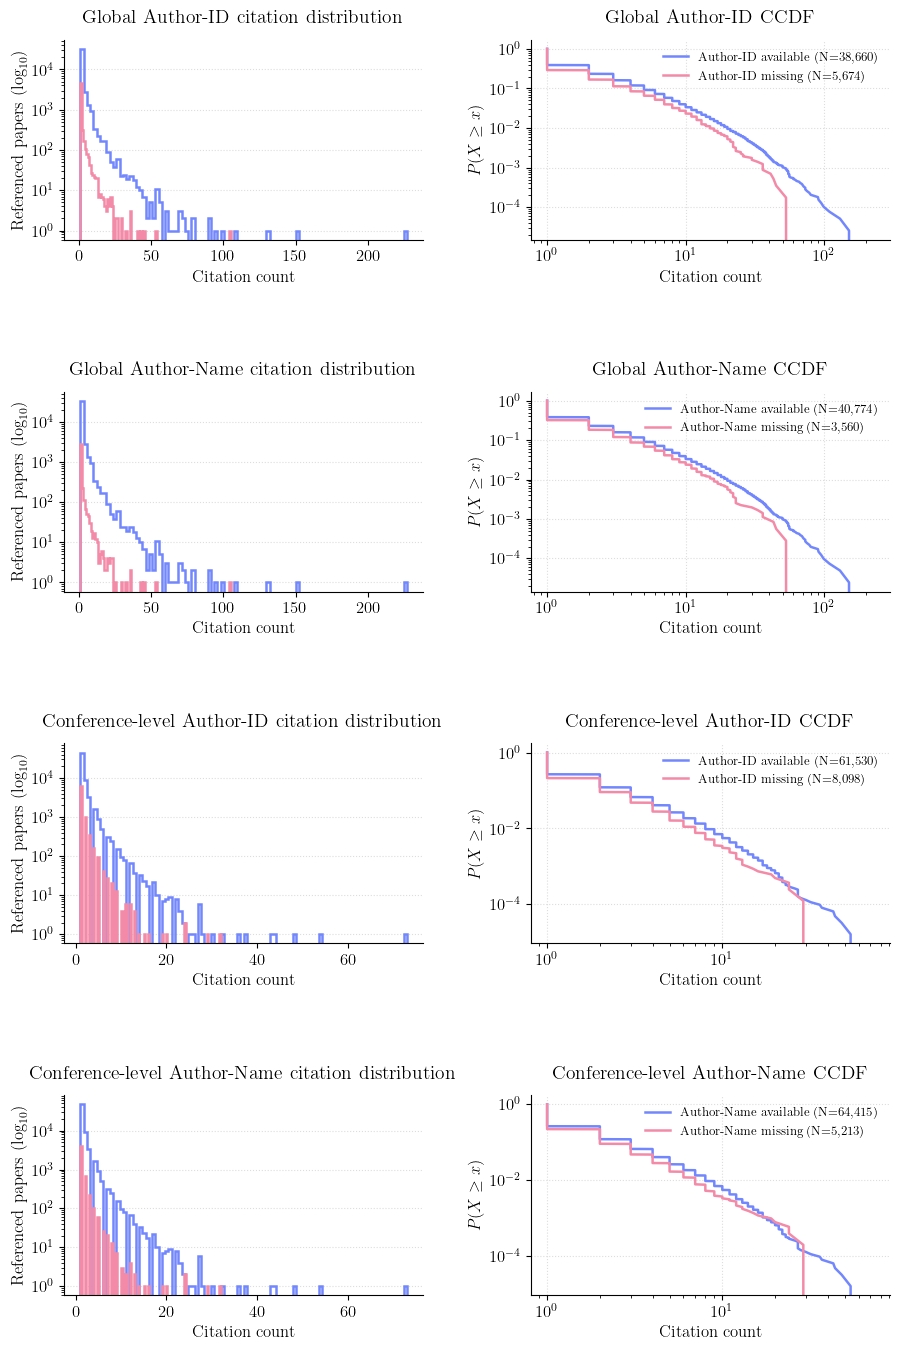

In [7]:
def citation_arrays(frame, availability_column):
    missing = frame[availability_column] == 0
    with_info = frame.loc[~missing, "citation_count"].dropna().values
    without_info = frame.loc[missing, "citation_count"].dropna().values
    return with_info, without_info


def ccdf(values):
    values = np.sort(values)
    return values, 1 - np.arange(1, len(values) + 1) / len(values)


def plot_distribution_pair(ax_hist, ax_ccdf, frame, availability_column, title_prefix, label_prefix):
    with_auth, without_auth = citation_arrays(frame, availability_column)
    n_with = len(with_auth)
    n_without = len(without_auth)

    ax_hist.hist(
        with_auth,
        bins=100,
        log=True,
        histtype="step",
        linewidth=1.8,
        color="#7287fd",
    )
    ax_hist.hist(
        without_auth,
        bins=100,
        log=True,
        histtype="step",
        linewidth=1.8,
        color="#f38ba8",
    )
    ax_hist.set_xlabel("Citation count")
    ax_hist.set_ylabel(r"Referenced papers ($\log_{10}$)")
    ax_hist.set_title(f"{title_prefix} citation distribution", pad=12)
    ax_hist.grid(axis="y", color="#DDDDDD", ls=":", linewidth=0.8)
    ax_hist.spines["top"].set_visible(False)
    ax_hist.spines["right"].set_visible(False)

    with_sorted, ccdf_with = ccdf(with_auth)
    without_sorted, ccdf_without = ccdf(without_auth)
    line1, = ax_ccdf.plot(with_sorted, ccdf_with, color="#7287fd", linewidth=1.8)
    line2, = ax_ccdf.plot(without_sorted, ccdf_without, color="#f38ba8", linewidth=1.8)
    ax_ccdf.set_xscale("log")
    ax_ccdf.set_yscale("log")
    ax_ccdf.set_xlabel("Citation count")
    ax_ccdf.set_ylabel(r"$P(X \geq x)$")
    ax_ccdf.set_title(f"{title_prefix} CCDF", pad=12)
    ax_ccdf.grid(axis="both", color="#DDDDDD", ls=":", linewidth=0.8)
    ax_ccdf.spines["top"].set_visible(False)
    ax_ccdf.spines["right"].set_visible(False)
    ax_ccdf.legend(
        [line1, line2],
        [
            f"{label_prefix} available (N={n_with:,})",
            f"{label_prefix} missing (N={n_without:,})",
        ],
        loc="upper right",
        frameon=False,
        fontsize=9,
    )


fig, axs = plt.subplots(
    4, 2,
    figsize=(9, 13.5),
    constrained_layout=False,
)
fig.subplots_adjust(left=0.10, right=0.98, top=0.97, bottom=0.06, hspace=0.76, wspace=0.30)

plot_distribution_pair(
    axs[0, 0], axs[0, 1],
    m_overall,
    "ref_authorships_count",
    "Global Author-ID",
    "Author-ID",
)
plot_distribution_pair(
    axs[1, 0], axs[1, 1],
    m_overall,
    "ref_author_name_count",
    "Global Author-Name",
    "Author-Name",
)
plot_distribution_pair(
    axs[2, 0], axs[2, 1],
    m_by_issue,
    "ref_authorships_count",
    "Conference-level Author-ID",
    "Author-ID",
)
plot_distribution_pair(
    axs[3, 0], axs[3, 1],
    m_by_issue,
    "ref_author_name_count",
    "Conference-level Author-Name",
    "Author-Name",
)

set_size(fig, size=(9, 13.5))
fig.savefig(IMAGES / "citation_distribution_referenced_papers.pdf", bbox_inches="tight")
plt.show()


## 8. Plot — Citation distribution per issue


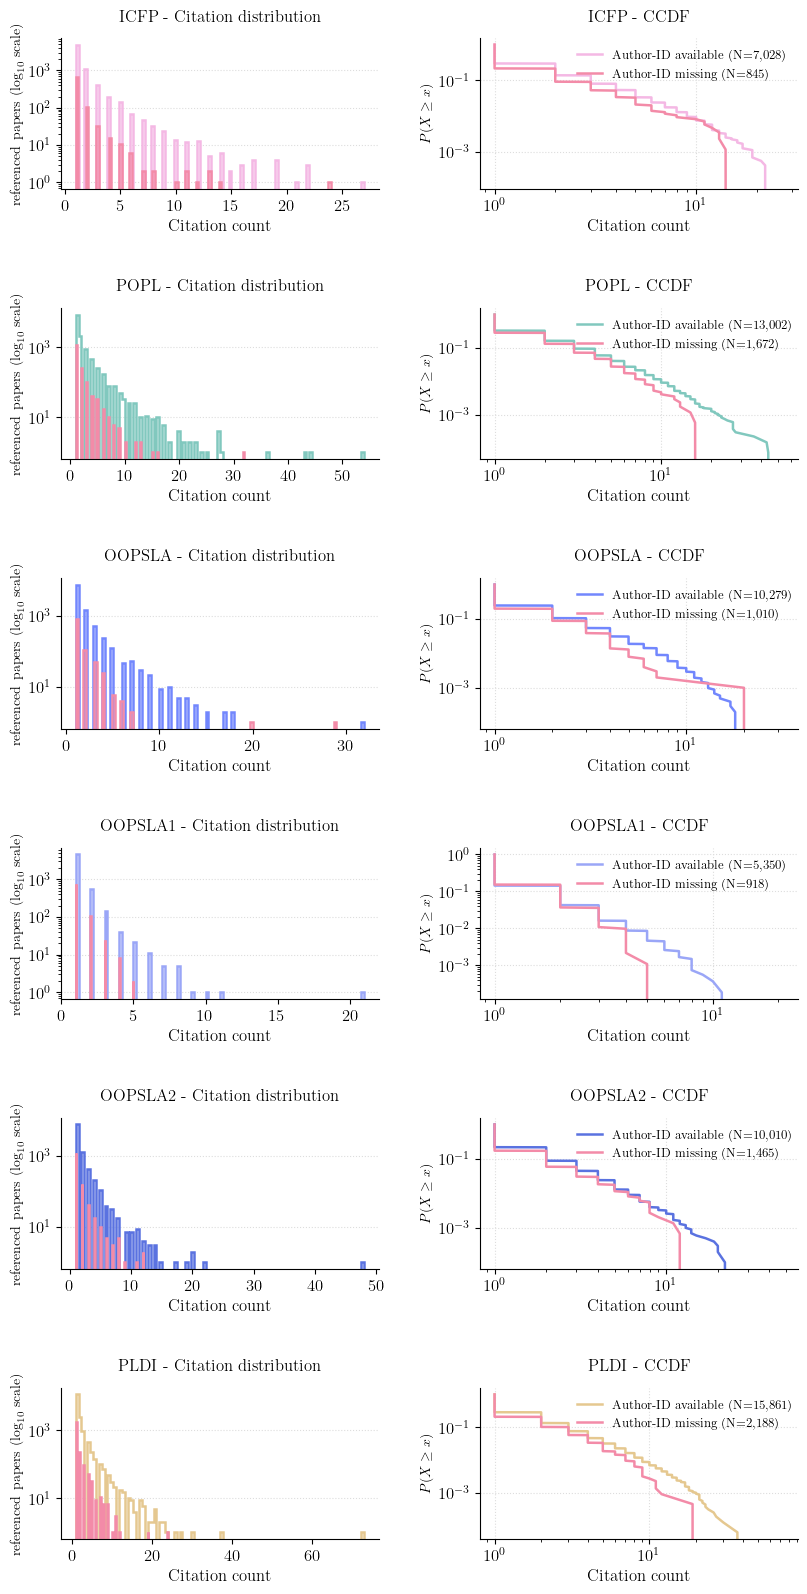

In [8]:
import matplotlib.pyplot as plt
import numpy as np

issues = sorted(m_by_issue["issue"].dropna().unique())

fig, axs = plt.subplots(
    len(issues), 2,
    figsize=(9.5, 3.25*len(issues)),
    constrained_layout=False
)
fig.subplots_adjust(hspace=0.78, wspace=0.32)
issues = [i for i in ISSUE_ORDER if i in m_by_issue["issue"].values]
for i, issue in enumerate(issues):

    df = m_by_issue[m_by_issue["issue"] == issue].copy()

    df["missing_authors"] = df["ref_authorships_count"] == 0

    with_auth = df.loc[~df["missing_authors"], "citation_count"].dropna().values
    without_auth = df.loc[df["missing_authors"], "citation_count"].dropna().values

    N_with = len(with_auth)
    N_without = len(without_auth)
    issue_color = COLORS[issue]
    missing_author_id_color = "#f38ba8"

    # ----------------------------------
    # CCDF
    # ----------------------------------

    with_sorted = np.sort(with_auth)
    without_sorted = np.sort(without_auth)

    ccdf_with = 1 - np.arange(1, len(with_sorted)+1) / len(with_sorted)
    ccdf_without = 1 - np.arange(1, len(without_sorted)+1) / len(without_sorted)

    # ----------------------------------
    # Histogram
    # ----------------------------------

    ax = axs[i,0]

    ax.hist(
        with_auth,
        bins=100,
        log=True,
        histtype="step",
        linewidth=1.8,
        color=issue_color,
        linestyle="-"
    )

    ax.hist(
        without_auth,
        bins=100,
        log=True,
        histtype="step",
        linewidth=1.8,
        color=missing_author_id_color,
        linestyle="-"
    )

    ax.set_title(f"{issue} - Citation distribution", pad=12, fontsize=12)

    ax.set_xlabel("Citation count")
    ax.set_ylabel(r"referenced papers ($\log_{10}$ scale)", fontsize=10)

    ax.grid(axis="y", color="#DDDDDD", ls=":", linewidth=0.8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # ----------------------------------
    # CCDF plot
    # ----------------------------------

    ax = axs[i,1]

    line1, = ax.plot(
        with_sorted,
        ccdf_with,
        color=issue_color,
        linewidth=1.8,
        linestyle="-"
    )

    line2, = ax.plot(
        without_sorted,
        ccdf_without,
        color=missing_author_id_color,
        linewidth=1.8,
        linestyle="-"
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_title(f"{issue} - CCDF", pad=12, fontsize=12)

    ax.set_xlabel("Citation count")
    ax.set_ylabel(r"$P(X \geq x)$", fontsize=10)

    ax.grid(axis="both", color="#DDDDDD", ls=":", linewidth=0.8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    axs[i,1].legend(
        [line1, line2],
        [
            f"Author-ID available (N={N_with:,})",
            f"Author-ID missing (N={N_without:,})"
        ],
        loc="upper left",
        bbox_to_anchor=(0.27, 1.0),
        frameon=False,
        fontsize=9
    )

fig.savefig(IMAGES / "citation_distribution_referenced_papers_issues.pdf",bbox_inches="tight")
plt.show()


## 9. Plot — Missing author rate over time

OOPSLA1 / OOPSLA2 are included alongside OOPSLA in the legend ordering.


In [9]:
def build_missing_metadata_by_year(frame, availability_column, metadata_type):
    stats = (
        frame.assign(missing_metadata=frame[availability_column] == 0)
        .groupby(["issue", "year"], as_index=False)
        .agg(
            total_referenced_works=("citation_count", "size"),
            missing_referenced_works=("missing_metadata", "sum"),
        )
    )
    stats["missing_rate"] = (
        stats["missing_referenced_works"] / stats["total_referenced_works"]
    )
    stats["metadata_type"] = metadata_type
    return stats


author_id_year_issue_stats = build_missing_metadata_by_year(
    m_by_issue_year,
    "ref_authorships_count",
    "Author-ID",
)
author_name_year_issue_stats = build_missing_metadata_by_year(
    m_by_issue_year,
    "ref_author_name_count",
    "Author-Name",
)

author_id_year_issue_stats.to_csv(
    TABLES / "missing_author_id_by_year.csv",
    index=False,
)
author_name_year_issue_stats.to_csv(
    TABLES / "missing_author_name_by_year.csv",
    index=False,
)


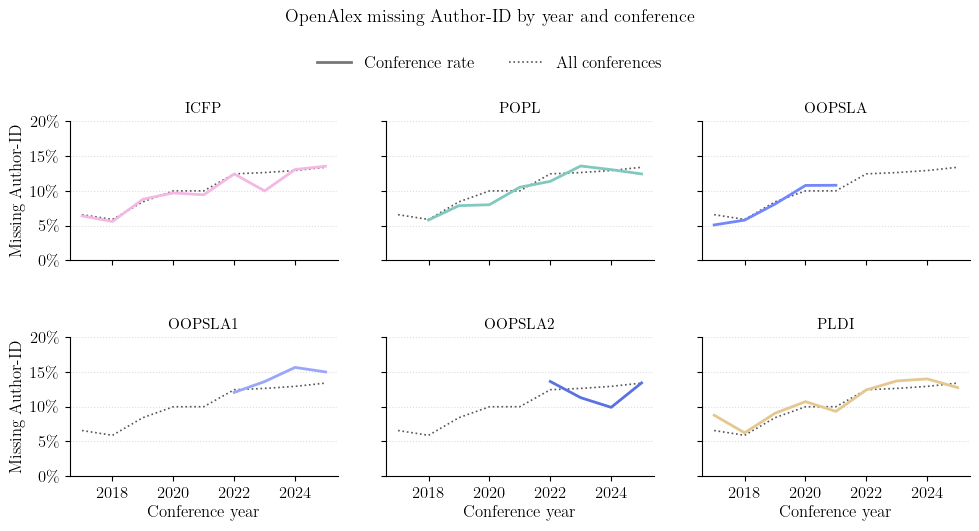

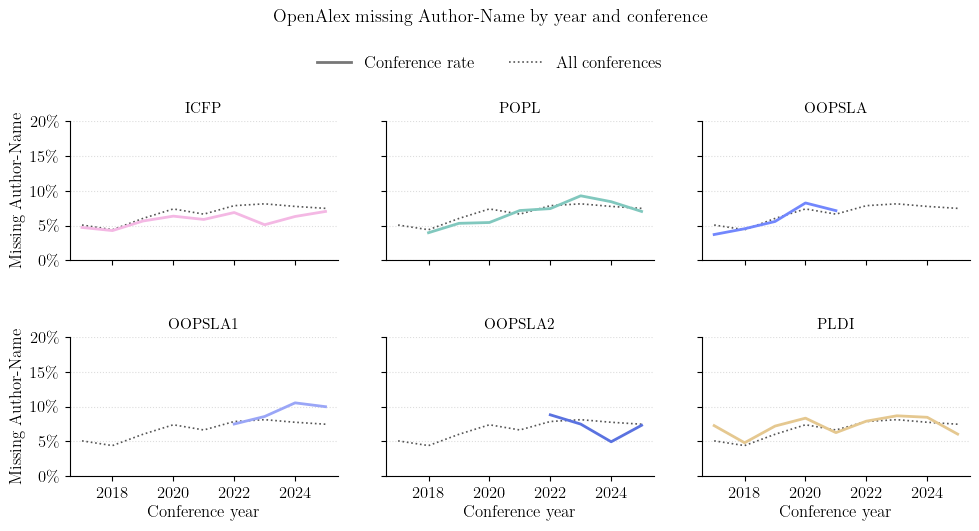

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter

colors = {
    "ICFP": "#f4b8e4",
    "POPL": "#81c8be",
    "OOPSLA": "#7287fd",
    "OOPSLA1": "#9aa6f7",
    "OOPSLA2": "#5a72e0",
    "PLDI": "#e5c890",
}


def build_overall_missing_by_year(frame, availability_column):
    overall = (
        frame.assign(missing_metadata=frame[availability_column] == 0)
        .groupby("year", as_index=False)
        .agg(
            total_referenced_works=("citation_count", "size"),
            missing_referenced_works=("missing_metadata", "sum"),
        )
        .sort_values("year")
    )
    overall["missing_rate"] = (
        overall["missing_referenced_works"] / overall["total_referenced_works"]
    )
    return overall


def plot_missing_metadata_small_multiples(stats, availability_column, metadata_label, output_names):
    issue_order = [i for i in ISSUE_ORDER if i in stats["issue"].values]
    overall = build_overall_missing_by_year(m_by_issue_year, availability_column)

    y_max = max(stats["missing_rate"].max(), overall["missing_rate"].max())
    y_upper = max(0.20, np.ceil((y_max + 0.02) / 0.05) * 0.05)

    fig, axs = plt.subplots(2, 3, figsize=(10, 5.3), sharex=True, sharey=True)
    axs = axs.ravel()

    for ax, issue in zip(axs, issue_order):
        sub = (
            stats.loc[stats["issue"] == issue]
            .sort_values("year")
            .copy()
        )

        ax.plot(
            overall["year"],
            overall["missing_rate"],
            color="#555555",
            linewidth=1.2,
            linestyle=":",
            label="All conferences",
        )
        ax.plot(
            sub["year"],
            sub["missing_rate"],
            color=colors[issue],
            linewidth=2.0,
            label=issue,
        )

        ax.set_title(issue, fontsize=11, pad=6)
        ax.set_ylim(0, y_upper)
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
        ax.grid(axis="y", color="#DDDDDD", ls=":", linewidth=0.8)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for ax in axs[len(issue_order):]:
        ax.axis("off")

    for ax in axs[-3:]:
        ax.set_xlabel("Conference year")

    for ax in axs[::3]:
        ax.set_ylabel(f"Missing {metadata_label}")

    handles = [
        Line2D([0], [0], color="#777777", linewidth=2.0),
        Line2D([0], [0], color="#555555", linewidth=1.2, linestyle=":"),
    ]
    labels = ["Conference rate", "All conferences"]
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.93),
        ncol=2,
        frameon=False,
    )
    fig.suptitle(f"OpenAlex missing {metadata_label} by year and conference", y=0.99, fontsize=13)
    fig.subplots_adjust(top=0.78, bottom=0.11, left=0.08, right=0.98, hspace=0.55, wspace=0.18)

    for output_name in output_names:
        fig.savefig(IMAGES / output_name, bbox_inches="tight")
    plt.show()


plot_missing_metadata_small_multiples(
    author_id_year_issue_stats,
    "ref_authorships_count",
    "Author-ID",
    [
        "openalex_author_id_metadata_missing.pdf",
    ],
)

plot_missing_metadata_small_multiples(
    author_name_year_issue_stats,
    "ref_author_name_count",
    "Author-Name",
    ["openalex_author_name_metadata_missing.pdf"],
)


## 10. Plot — References per paper boxplots

This plot summarizes the distribution of reference counts per accepted paper.


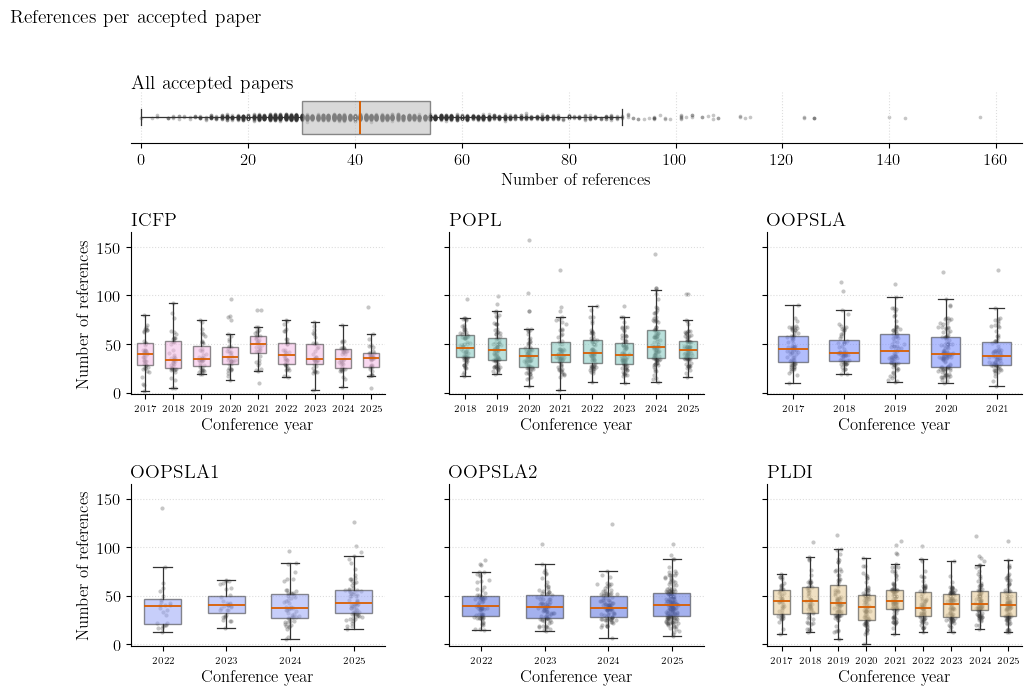

In [11]:
df_box = df_filtered.copy(deep=True)
df_box["volume"] = pd.to_numeric(df_box["conference_year"])
df_box["number_of_references"] = pd.to_numeric(df_box["number_of_references"])

colors = {
    "ICFP": "#f4b8e4",
    "POPL": "#81c8be",
    "OOPSLA": "#7287fd",
    "OOPSLA1": "#9aa6f7",
    "OOPSLA2": "#5a72e0",
    "PLDI": "#e5c890",
}
issue_order = ISSUE_ORDER
issues = [i for i in issue_order if i in df_box["issue"].unique()]
rng = np.random.default_rng(7)
ymax = max(110, df_box["number_of_references"].max() * 1.05)

fig = plt.figure(figsize=(11.5, 7.2))
gs = fig.add_gridspec(3, 3, height_ratios=[1.0, 3.2, 3.2], wspace=0.25, hspace=0.72)

ax_top = fig.add_subplot(gs[0, :])
all_refs = df_box["number_of_references"].dropna().to_numpy()
y_jitter = rng.normal(1.0, 0.025, size=len(all_refs))
ax_top.scatter(all_refs, y_jitter, s=7, color="#333333", alpha=0.28, linewidths=0, zorder=1)
bp = ax_top.boxplot(
    all_refs,
    vert=False,
    widths=0.65,
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "#d95f02", "linewidth": 1.4},
    whiskerprops={"color": "#333333", "linewidth": 0.9},
    capprops={"color": "#333333", "linewidth": 0.9},
)
for patch in bp["boxes"]:
    patch.set_facecolor("#bbbbbb")
    patch.set_alpha(0.55)
    patch.set_edgecolor("#333333")

ax_top.set_title("All accepted papers", loc="left", pad=2)
ax_top.set_xlabel("Number of references")
ax_top.grid(axis="x", color="#DDDDDD", ls=":", linewidth=0.8)
ax_top.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)
ax_top.spines["left"].set_visible(False)
ax_top.set_yticks([])
ax_top.set_xlim(-2, ymax)

axs = []
for i, issue in enumerate(issues):
    row = 1 + i // 3
    col = i % 3
    ax = fig.add_subplot(gs[row, col], sharey=axs[0] if axs else None)
    axs.append(ax)

    sub = df_box[df_box["issue"] == issue]
    volumes = sorted(sub["volume"].dropna().unique())
    positions = np.arange(len(volumes))
    data = [sub.loc[sub["volume"] == v, "number_of_references"].dropna().to_numpy() for v in volumes]

    for pos, values in zip(positions, data):
        jitter = rng.normal(pos, 0.055, size=len(values))
        ax.scatter(jitter, values, s=9, color="#333333", alpha=0.28, linewidths=0, zorder=1)

    bp = ax.boxplot(
        data,
        positions=positions,
        widths=0.58,
        patch_artist=True,
        showfliers=False,
        medianprops={"color": "#d95f02", "linewidth": 1.3},
        whiskerprops={"color": "#333333", "linewidth": 0.9},
        capprops={"color": "#333333", "linewidth": 0.9},
    )
    for patch in bp["boxes"]:
        patch.set_facecolor(colors.get(issue, "#999999"))
        patch.set_alpha(0.55)
        patch.set_edgecolor("#333333")

    ax.set_title(issue, loc="left", pad=5)
    ax.set_xlabel("Conference year")
    ax.set_xticks(positions)
    ax.set_xticklabels([str(int(v)) for v in volumes], rotation=0, ha="center")
    ax.set_ylim(-2, ymax)
    ax.grid(axis="y", color="#DDDDDD", ls=":", linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for ax in axs[::3]:
    ax.set_ylabel("Number of references")

for ax in axs:
    ax.tick_params(axis="x", labelsize=7)

for ax in axs[1:3] + axs[4:6]:
    ax.tick_params(labelleft=False)

for i in range(len(issues), 6):
    fig.add_subplot(gs[1 + i // 3, i % 3]).axis("off")

fig.suptitle("References per accepted paper", x=0.02, y=0.995, ha="left", fontsize=14)
fig.savefig(IMAGES / "references_boxplots_with_overall.pdf", bbox_inches="tight")
plt.show()


## Output

| File | Description |
|---|---|
| `number_of_authors_for_referenced_work.pdf` | Author count check for referenced works |
| `number_of_authors_for_referenced_work_conferences.pdf` | Author count check by conference, including PLDI |
| `citation_distribution_referenced_papers.pdf` | Global citation count check for referenced works |
| `citation_distribution_referenced_papers_issues.pdf` | Citation count check by conference, including PLDI |
| `openalex_author_id_metadata_missing.pdf` | Explicit Author ID version of missing metadata by year and conference |
| `openalex_author_name_metadata_missing.pdf` | Author Name version of missing metadata by year and conference |
| `references_boxplots_with_overall.pdf` | Reference count distribution per accepted paper |
| `openalex_duplicate_cited_title_summary.csv` | Summary of cited title groups that map to multiple OpenAlex work IDs |
| `duplicate_titles_exploded.csv` | Cited title duplicate work ID examples in the exploded author set |
| `duplicate_titles_ref_edges.csv` | Cited title duplicate work ID examples in raw reference edges |
